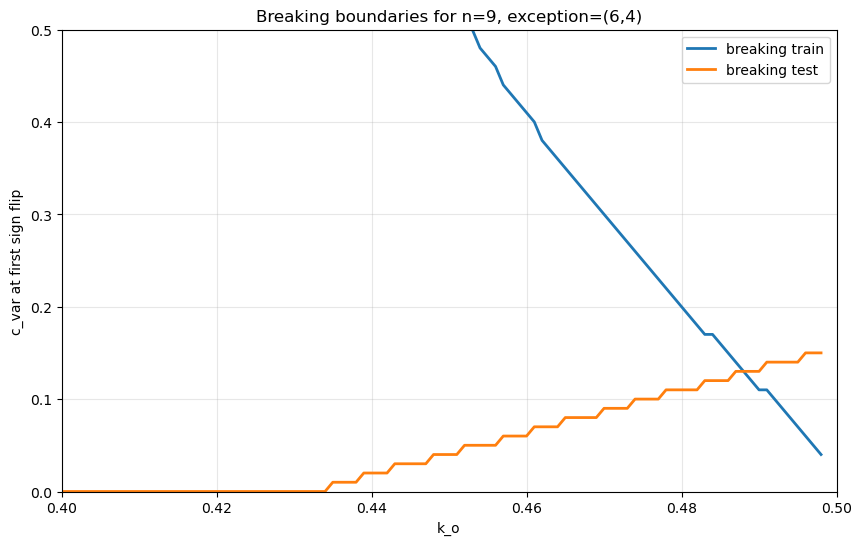

In [4]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on path so Ranking_exp imports reliably from this notebook.
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Ranking_exp import Ranking_exp

# Parameters: n = 9, exception at (p, q) = (6, 4)
n = 9
p, q = 6, 4
k_s, k_d = 1.0, 0.0

delta_s = k_s - k_d
k_o_vals = np.arange(0.4, 0.499, 0.001)
c_var_vals = np.arange(1e-4, 10, 0.01)
c_vals = 1.0 / (c_var_vals * delta_s)

# Critical pairs used in your original logic
test_pair = (q - 1, p)   # (3, 6)
train_pair = (q, q + 1)  # (4, 5)

breaking_reg_test = []
breaking_reg_train = []

for k_o in k_o_vals:
    # Test boundary: first c_var where margin becomes negative
    test_break = 0.0
    for c_var, c_reg in zip(c_var_vals, c_vals):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
        if sim.f_j_k(*test_pair) < 0:
            test_break = c_var
            break
    breaking_reg_test.append(test_break)

    # Train boundary: first c_var where margin becomes negative
    train_break = 0.0
    for c_var, c_reg in zip(c_var_vals, c_vals):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
        if sim.f_j_k(*train_pair) < 0:
            train_break = c_var
            break
    breaking_reg_train.append(train_break)

# ---- Plot 1: phase/break diagram ----
plt.figure(figsize=(10, 6))
plt.plot(k_o_vals, breaking_reg_train, label='breaking train', linewidth=2)
plt.plot(k_o_vals, breaking_reg_test, label='breaking test', linewidth=2)
plt.title(f'Breaking boundaries for n={n}, exception=({p},{q})')
plt.xlabel('k_o')
plt.ylabel('c_var at first sign flip')
plt.xlim(0.40, 0.50)
plt.ylim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


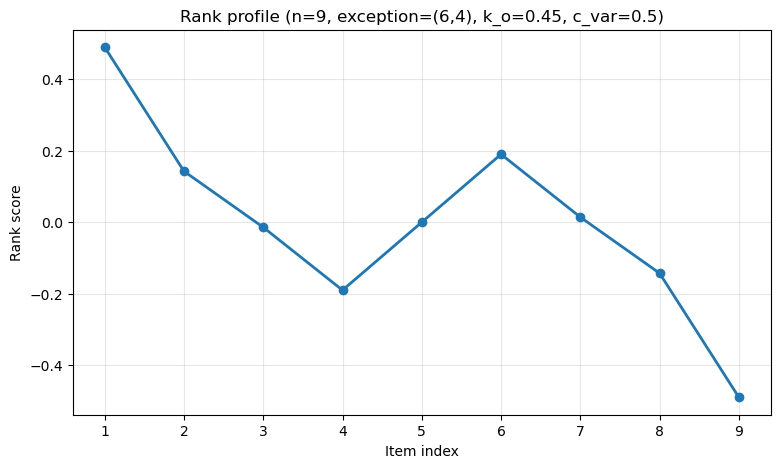

In [5]:

# ---- Plot 2: ranking profile at one sample (k_o, c_var) ----
k_o_demo = 0.45
c_var_demo = 0.5
c_reg_demo = 1.0 / (c_var_demo * delta_s)

sim_demo = Ranking_exp(n=n, k_o=k_o_demo, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_demo)
ranks_demo = sim_demo.calc_rank_analytic()

plt.figure(figsize=(9, 5))
idx = np.arange(1, n + 1)
plt.plot(idx, ranks_demo, marker='o', linewidth=2)
plt.title(f'Rank profile (n={n}, exception=({p},{q}), k_o={k_o_demo}, c_var={c_var_demo})')
plt.xlabel('Item index')
plt.ylabel('Rank score')
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

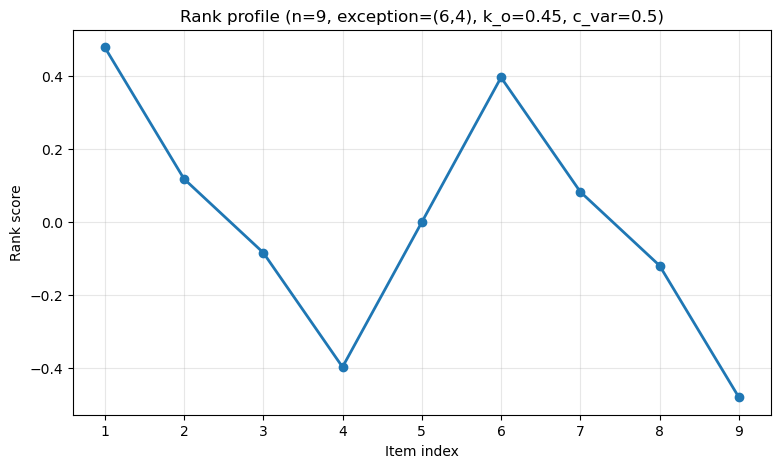

In [6]:


# ---- Plot 2: ranking profile at one sample (k_o, c_var) ----
k_o_demo = 0.45
c_var_demo = .5
c_reg_demo = 1.0 / (c_var_demo * delta_s)

sim_demo = Ranking_exp(n=n, k_o=k_o_demo, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_demo)
ranks_demo = sim_demo.calc_rank()

plt.figure(figsize=(9, 5))
idx = np.arange(1, n + 1)
plt.plot(idx, ranks_demo, marker='o', linewidth=2)
plt.title(f'Rank profile (n={n}, exception=({p},{q}), k_o={k_o_demo}, c_var={c_var_demo})')
plt.xlabel('Item index')
plt.ylabel('Rank score')
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np
from Ranking_exp import Ranking_exp

# try a few different parameter settings
configs = [
    dict(n=7, p=2, q=5, k_o=0.1, k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=2.0),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=7, p=3, q=5, k_o=0.2, k_s=1.0, k_d=0.0, c_reg=10.0),
]

for cfg in configs:
    sim = Ranking_exp(**cfg)
    ra = sim.calc_rank_analytic()
    r  = sim.calc_rank()
    print(f"cfg={cfg}")
    print(f"  calc_rank_analytic: {np.round(ra, 5)}")
    print(f"  calc_rank         : {np.round(r,  5)}")
    print(f"  max |diff|        : {np.max(np.abs(ra - r)):.3e}")
    print()

cfg={'n': 7, 'p': 2, 'q': 5, 'k_o': 0.1, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 1000000.0}
  calc_rank_analytic: [ 1.1232e-01  1.0840e-02  1.0900e-03  5.0000e-05 -6.2000e-04 -1.1300e-02
 -1.1237e-01]
  calc_rank         : [ 0.12167  0.09506  0.00875 -0.0076  -0.08476 -0.01981 -0.11331]
  max |diff|        : 8.422e-02

cfg={'n': 9, 'p': 6, 'q': 4, 'k_o': 0.45, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 2.0}
  calc_rank_analytic: [ 0.4897   0.14263 -0.01426 -0.19017  0.       0.19017  0.01426 -0.14263
 -0.4897 ]
  calc_rank         : [ 0.4795   0.11884 -0.08337 -0.39674 -0.       0.39674  0.08337 -0.11884
 -0.4795 ]
  max |diff|        : 2.066e-01

cfg={'n': 9, 'p': 6, 'q': 4, 'k_o': 0.45, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 1000000.0}
  calc_rank_analytic: [ 1.45328  0.77623  0.27168 -0.1725   0.       0.1725  -0.27168 -0.77623
 -1.45328]
  calc_rank         : [ 1.45327  0.77623  0.27168 -0.1725  -0.       0.1725  -0.27168 -0.77623
 -1.45327]
  max |diff|        : 1.840e-06

cfg={'n': 7, 'p': 3, 'q': 5, '

In [8]:
import numpy as np
from Ranking_exp import Ranking_exp

def ground_truth_rank(sim):
    """Compute the true r_j directly from the solved dual coefficients."""
    _ = sim.calc_rank()            # populates sim.a_exp
    n, p, q = sim.n, sim.p, sim.q
    ap = sim.alpha_prime

    a_exp = sim.a_exp
    b = {i: a_exp[i-1] for i in range(1, n)}   # b_1 .. b_{n-1}
    b[0] = 0.0
    b[n] = 0.0
    c = a_exp[2*(n-1)]                         # the exception coefficient c

    def delta(i, j): return 1.0 if i == j else 0.0

    ranks = np.zeros(n)
    for j in range(1, n+1):
        ranks[j-1] = ap * (b[j] - b[j-1]) + ap * c * (delta(j, p) - delta(j, q))
    return ranks, c

configs = [
    dict(n=7, p=2, q=5, k_o=0.1,  k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=2.0),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=7, p=3, q=5, k_o=0.2,  k_s=1.0, k_d=0.0, c_reg=10.0),
]

for cfg in configs:
    sim = Ranking_exp(**cfg)
    truth, c_true = ground_truth_rank(sim)
    ra = sim.calc_rank_analytic()
    r  = sim.calc_rank()
    print(f"cfg={cfg}")
    print(f"  ground truth       : {np.round(truth, 5)}   (c_true = {c_true:.5f})")
    print(f"  calc_rank          : {np.round(r,     5)}   max|err|={np.max(np.abs(r  - truth)):.2e}")
    print(f"  calc_rank_analytic : {np.round(ra,    5)}   max|err|={np.max(np.abs(ra - truth)):.2e}")
    print()

cfg={'n': 7, 'p': 2, 'q': 5, 'k_o': 0.1, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 1000000.0}
  ground truth       : [ 0.12167  0.09506  0.00875 -0.0076  -0.08476 -0.01981 -0.11331]   (c_true = 1.02523)
  calc_rank          : [ 0.12167  0.09506  0.00875 -0.0076  -0.08476 -0.01981 -0.11331]   max|err|=8.69e-08
  calc_rank_analytic : [ 1.1232e-01  1.0840e-02  1.0900e-03  5.0000e-05 -6.2000e-04 -1.1300e-02
 -1.1237e-01]   max|err|=8.42e-02

cfg={'n': 9, 'p': 6, 'q': 4, 'k_o': 0.45, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 2.0}
  ground truth       : [ 0.4897   0.14263 -0.01426 -0.19017  0.       0.19017  0.01426 -0.14263
 -0.4897 ]   (c_true = 1.03275)
  calc_rank          : [ 0.4795   0.11884 -0.08337 -0.39674 -0.       0.39674  0.08337 -0.11884
 -0.4795 ]   max|err|=2.07e-01
  calc_rank_analytic : [ 0.4897   0.14263 -0.01426 -0.19017  0.       0.19017  0.01426 -0.14263
 -0.4897 ]   max|err|=3.89e-16

cfg={'n': 9, 'p': 6, 'q': 4, 'k_o': 0.45, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 1000000.0}
  ground truth    

(p,q)=(3,6):  pass(<1e-6)=0/625   fail(>=1e-6)=625
   median err = 1.56e-01, max err = 1.52e+00

(p,q)=(6,3):  pass(<1e-6)=625/625   fail(>=1e-6)=0
   median err = 2.08e-16, max err = 2.94e-13



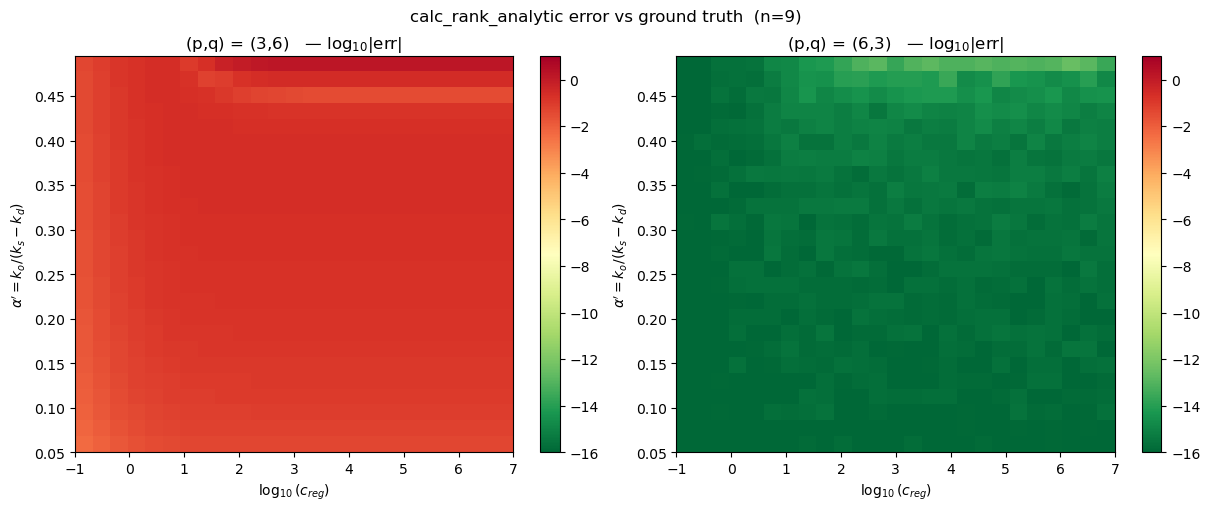

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

def ground_truth_rank(sim):
    """True r_j from the solved dual coefficients."""
    _ = sim.calc_rank()
    n, p, q = sim.n, sim.p, sim.q
    ap = sim.alpha_prime
    a_exp = sim.a_exp
    b = {i: a_exp[i-1] for i in range(1, n)}
    b[0] = 0.0
    b[n] = 0.0
    c = a_exp[2*(n-1)]
    def delta(i, j): return 1.0 if i == j else 0.0
    ranks = np.zeros(n)
    for j in range(1, n+1):
        ranks[j-1] = ap * (b[j] - b[j-1]) + ap * c * (delta(j, p) - delta(j, q))
    return ranks

# ------------------------------------------------------------
# Sweep setup
# ------------------------------------------------------------
n = 9
k_s, k_d = 1.0, 0.0

# alpha_prime = k_o / (k_s - k_d) = k_o  (since k_s=1, k_d=0)
# alpha_prime in (0, 0.5) to keep 1 - 2*alpha_prime > 0
alpha_prime_vals = np.linspace(0.05, 0.495, 25)
c_reg_vals       = np.logspace(-1, 7, 25)   # 0.1 up to 1e7

# Try both orderings
pq_pairs = [(3, 6), (6, 3)]   # (p<q) and (p>q)

results = {}
for (p, q) in pq_pairs:
    err_grid = np.full((len(alpha_prime_vals), len(c_reg_vals)), np.nan)
    for i, ap in enumerate(alpha_prime_vals):
        for j, cr in enumerate(c_reg_vals):
            try:
                sim = Ranking_exp(n=n, k_o=ap, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=cr)
                truth = ground_truth_rank(sim)
                pred  = sim.calc_rank_analytic()
                err_grid[i, j] = np.max(np.abs(pred - truth))
            except Exception as e:
                err_grid[i, j] = np.nan
    results[(p, q)] = err_grid

# ------------------------------------------------------------
# Print worst-case and summary
# ------------------------------------------------------------
for (p, q), err in results.items():
    finite = err[np.isfinite(err)]
    ok = (finite < 1e-6).sum()
    bad = (finite >= 1e-6).sum()
    print(f"(p,q)=({p},{q}):  pass(<1e-6)={ok}/{finite.size}   fail(>=1e-6)={bad}")
    print(f"   median err = {np.median(finite):.2e}, "
          f"max err = {np.max(finite):.2e}")
    print()

# ------------------------------------------------------------
# Heatmaps
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(pq_pairs), figsize=(6*len(pq_pairs), 5),
                         constrained_layout=True)
if len(pq_pairs) == 1:
    axes = [axes]

for ax, (p, q) in zip(axes, pq_pairs):
    err = results[(p, q)]
    im = ax.imshow(
        np.log10(err + 1e-300),
        origin='lower', aspect='auto',
        extent=[np.log10(c_reg_vals[0]),  np.log10(c_reg_vals[-1]),
                alpha_prime_vals[0],      alpha_prime_vals[-1]],
        vmin=-16, vmax=1, cmap='RdYlGn_r'
    )
    ax.set_xlabel(r'$\log_{10}(c_{reg})$')
    ax.set_ylabel(r"$\alpha' = k_o / (k_s - k_d)$")
    ax.set_title(f'(p,q) = ({p},{q})   — log$_{{10}}$|err|')
    plt.colorbar(im, ax=ax)

fig.suptitle(f'calc_rank_analytic error vs ground truth  (n={n})')
plt.show()

  n   p   q    max|err|   worst (alpha_prime, c_reg)
----------------------------------------------------------------------
  7   7   2    4.55e-13   (0.495, 1.4e+04)
  5   5   2    4.39e-13   (0.495, 1.4e+04)
  7   7   4    4.23e-13   (0.495, 7.2e+05)
 13   9   6    4.11e-13   (0.495, 1.0e+07)
 11   9   6    4.02e-13   (0.495, 1.0e+07)
 13   5   2    3.59e-13   (0.495, 1.4e+04)
  9   9   6    3.51e-13   (0.495, 1.4e+04)
  7   5   2    3.49e-13   (0.495, 1.4e+04)
  9   5   2    3.48e-13   (0.495, 1.4e+04)
 13  11   8    3.46e-13   (0.495, 1.0e+07)
 11   5   2    3.38e-13   (0.495, 1.4e+04)
  9   8   5    3.32e-13   (0.495, 2.7e+06)
 11   8   5    3.25e-13   (0.495, 2.7e+06)
 13  11   2    3.19e-13   (0.495, 1.0e+07)
 13   8   5    3.16e-13   (0.495, 2.7e+06)
 13  10   7    3.16e-13   (0.495, 1.0e+07)
 11  10   7    3.14e-13   (0.495, 1.0e+07)
 13  11   6    3.12e-13   (0.495, 1.0e+07)
  9   7   2    3.07e-13   (0.495, 1.4e+04)
 13   7   2    3.06e-13   (0.495, 1.4e+04)
 11   7   2    3

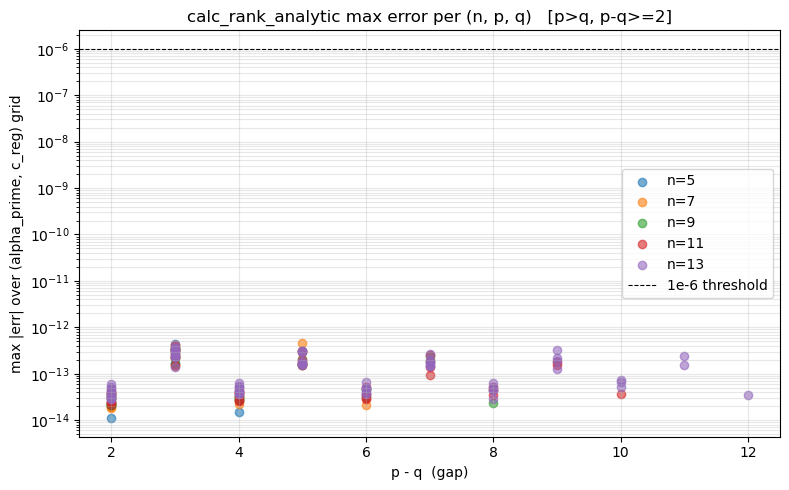

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

def ground_truth_rank(sim):
    _ = sim.calc_rank()
    n, p, q = sim.n, sim.p, sim.q
    ap = sim.alpha_prime
    a_exp = sim.a_exp
    b = {i: a_exp[i-1] for i in range(1, n)}
    b[0] = 0.0
    b[n] = 0.0
    c = a_exp[2*(n-1)]
    def delta(i, j): return 1.0 if i == j else 0.0
    ranks = np.zeros(n)
    for j in range(1, n+1):
        ranks[j-1] = ap * (b[j] - b[j-1]) + ap * c * (delta(j, p) - delta(j, q))
    return ranks

# ------------------------------------------------------------
# Sweep setup
# ------------------------------------------------------------
n_vals           = [5, 7, 9, 11, 13]
alpha_prime_vals = np.linspace(0.05, 0.495, 15)
c_reg_vals       = np.logspace(-1, 7, 15)

records = []   # (n, p, q, max_err, argmax config)
for n in n_vals:
    for q in range(1, n+1):
        for p in range(q+2, n+1):     # p > q and p - q >= 2
            max_err = 0.0
            worst_cfg = None
            for ap in alpha_prime_vals:
                for cr in c_reg_vals:
                    try:
                        sim = Ranking_exp(n=n, k_o=ap, k_s=1.0, k_d=0.0,
                                          p=p, q=q, c_reg=cr)
                        truth = ground_truth_rank(sim)
                        pred  = sim.calc_rank_analytic()
                        err   = np.max(np.abs(pred - truth))
                    except Exception:
                        err = np.nan
                    if np.isfinite(err) and err > max_err:
                        max_err  = err
                        worst_cfg = (ap, cr)
            records.append((n, p, q, max_err, worst_cfg))

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
records.sort(key=lambda r: -r[3])     # worst first

print(f"{'n':>3} {'p':>3} {'q':>3}  {'max|err|':>10}   worst (alpha_prime, c_reg)")
print("-" * 70)
for n, p, q, e, cfg in records:
    cfg_str = f"({cfg[0]:.3f}, {cfg[1]:.1e})" if cfg else "-"
    flag = ""
    if e > 1e-6: flag = "  <-- FAIL"
    print(f"{n:>3} {p:>3} {q:>3}  {e:>10.2e}   {cfg_str}{flag}")

n_fail = sum(1 for r in records if r[3] > 1e-6)
n_tot  = len(records)
print(f"\n{n_tot - n_fail}/{n_tot} configs pass (max error < 1e-6).")

# ------------------------------------------------------------
# Optional: plot max error per (n, p-q gap)
# ------------------------------------------------------------
errs_by_n = {n: [] for n in n_vals}
for n, p, q, e, _ in records:
    errs_by_n[n].append((p - q, e))

plt.figure(figsize=(8, 5))
for n in n_vals:
    gaps, es = zip(*errs_by_n[n])
    plt.scatter(gaps, es, label=f"n={n}", alpha=0.6)
plt.yscale('log')
plt.xlabel('p - q  (gap)')
plt.ylabel('max |err| over (alpha_prime, c_reg) grid')
plt.title("calc_rank_analytic max error per (n, p, q)   [p>q, p-q>=2]")
plt.axhline(1e-6, color='k', linestyle='--', linewidth=0.8, label='1e-6 threshold')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:


# ---- Plot 2: ranking profile at one sample (k_o, c_var) ----
k_o_demo = 0.45
c_var_demo = .5
c_reg_demo = 1.0 / (c_var_demo * delta_s)

sim_demo = Ranking_exp(n=n, k_o=k_o_demo, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_demo)
ranks_demo = sim_demo.calc_rank()

plt.figure(figsize=(9, 5))
idx = np.arange(1, n + 1)
plt.plot(idx, ranks_demo, marker='o', linewidth=2)
plt.title(f'Rank profile (n={n}, exception=({p},{q}), k_o={k_o_demo}, c_var={c_var_demo})')
plt.xlabel('Item index')
plt.ylabel('Rank score')
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

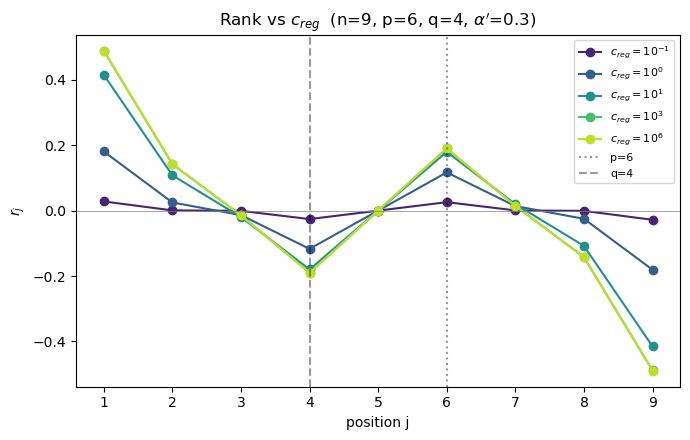

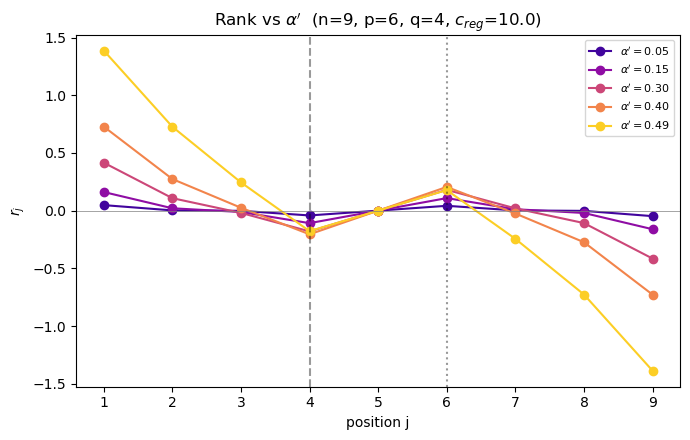

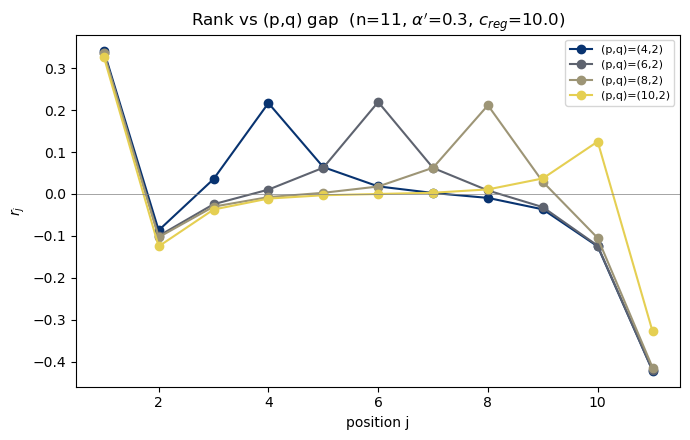

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

def rank_profile(n, p, q, k_o, c_reg, k_s=1.0, k_d=0.0):
    sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
    return sim.calc_rank_analytic()

# ------------------------------------------------------------
# Plot 1: sweep c_reg at fixed (n, p, q, alpha_prime)
# ------------------------------------------------------------
n, p, q = 9, 6, 4
alpha_prime = 0.3
c_reg_list = [1e-1, 1e0, 1e1, 1e3, 1e6]   # 5 systems

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(1, n + 1)
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(c_reg_list)))
for cr, col in zip(c_reg_list, cmap):
    r = rank_profile(n, p, q, alpha_prime, cr)
    ax.plot(x, r, marker='o', color=col, label=fr'$c_{{reg}}=10^{{{int(np.log10(cr))}}}$')
ax.axvline(p, color='k', ls=':', alpha=0.4, label=f'p={p}')
ax.axvline(q, color='k', ls='--', alpha=0.4, label=f'q={q}')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'$r_j$')
ax.set_title(fr"Rank vs $c_{{reg}}$  (n={n}, p={p}, q={q}, $\alpha'$={alpha_prime})")
ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# Plot 2: sweep alpha_prime at fixed (n, p, q, c_reg)
# ------------------------------------------------------------
n, p, q = 9, 6, 4
c_reg = 10.0
alpha_list = [0.05, 0.15, 0.30, 0.40, 0.49]   # 5 systems, all < 0.5

fig, ax = plt.subplots(figsize=(7, 4.5))
cmap = plt.cm.plasma(np.linspace(0.1, 0.9, len(alpha_list)))
for ap, col in zip(alpha_list, cmap):
    r = rank_profile(n, p, q, ap, c_reg)
    ax.plot(x, r, marker='o', color=col, label=fr"$\alpha'={ap:.2f}$")
ax.axvline(p, color='k', ls=':', alpha=0.4)
ax.axvline(q, color='k', ls='--', alpha=0.4)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'$r_j$')
ax.set_title(fr"Rank vs $\alpha'$  (n={n}, p={p}, q={q}, $c_{{reg}}$={c_reg})")
ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# Plot 3: sweep (p, q) gap at fixed n, alpha_prime, c_reg
# ------------------------------------------------------------
n = 11
alpha_prime = 0.3
c_reg = 10.0
pq_list = [(4, 2), (6, 2), (8, 2), (10, 2)]   # 4 systems, all p>q, p-q>=2

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(1, n + 1)
cmap = plt.cm.cividis(np.linspace(0.1, 0.9, len(pq_list)))
for (p, q), col in zip(pq_list, cmap):
    r = rank_profile(n, p, q, alpha_prime, c_reg)
    ax.plot(x, r, marker='o', color=col, label=f'(p,q)=({p},{q})')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'$r_j$')
ax.set_title(fr"Rank vs (p,q) gap  (n={n}, $\alpha'$={alpha_prime}, $c_{{reg}}$={c_reg})")
ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()